# Attir E-Commerce — Python Analytics Dashboard
### Bonus Task | Data Management Final Project
This notebook connects to the Attir relational database exported from MySQL and builds two analytical dashboards using Python (pandas + matplotlib). The data covers Attir's customers, orders, products, inventory, shipments, couriers, vendors, and returns from 2020 to 2024.

## 1. Imports
Loading the required Python libraries for data manipulation and visualization.

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

## 2. Load Tables
Reading all 17 CSV files exported from the Attir MySQL database into pandas DataFrames using Apache Spark.

In [0]:
BASE = "dbfs:/Workspace/Users/mmansharamani.msc2026@ivey.ca/Data Management Final Project/"

def load(name):
    path = BASE + name + ".csv"
    return spark.read.option("header", True).option("inferSchema", True).csv(path).toPandas()

courier         = load("courier")
customer        = load("customer")
inventory       = load("inventory")
inventory_mov   = load("inventory_movement")
location        = load("location")
order           = load("order")
order_item      = load("order_item")
payment         = load("payment")
po_item         = load("po_item")
product         = load("product")
product_variant = load("product_variant")
product_vendor  = load("product_vendor")
purchase_order  = load("purchase_order")
refund          = load("refund")
ret             = load("return")
shipment        = load("shipment")
vendor          = load("vendor")

print("All tables loaded!")

All tables loaded!


## 3. Dashboard 1 — Sales & Returns
This dashboard explores Attir's sales performance and returns data across five visualizations:
- **Return Rate by Product** — identifies which products have the highest return rates and flags those exceeding the 15% threshold
- **Courier Return Rate** — compares courier reliability to support contract renegotiation decisions
- **Monthly Gross vs Net Revenue** — tracks revenue growth over time accounting for all refunds
- **Return Reasons Breakdown** — categorizes why customers are returning items
- **Top 10 Products by Revenue** — highlights Attir's best performing products by total sales value

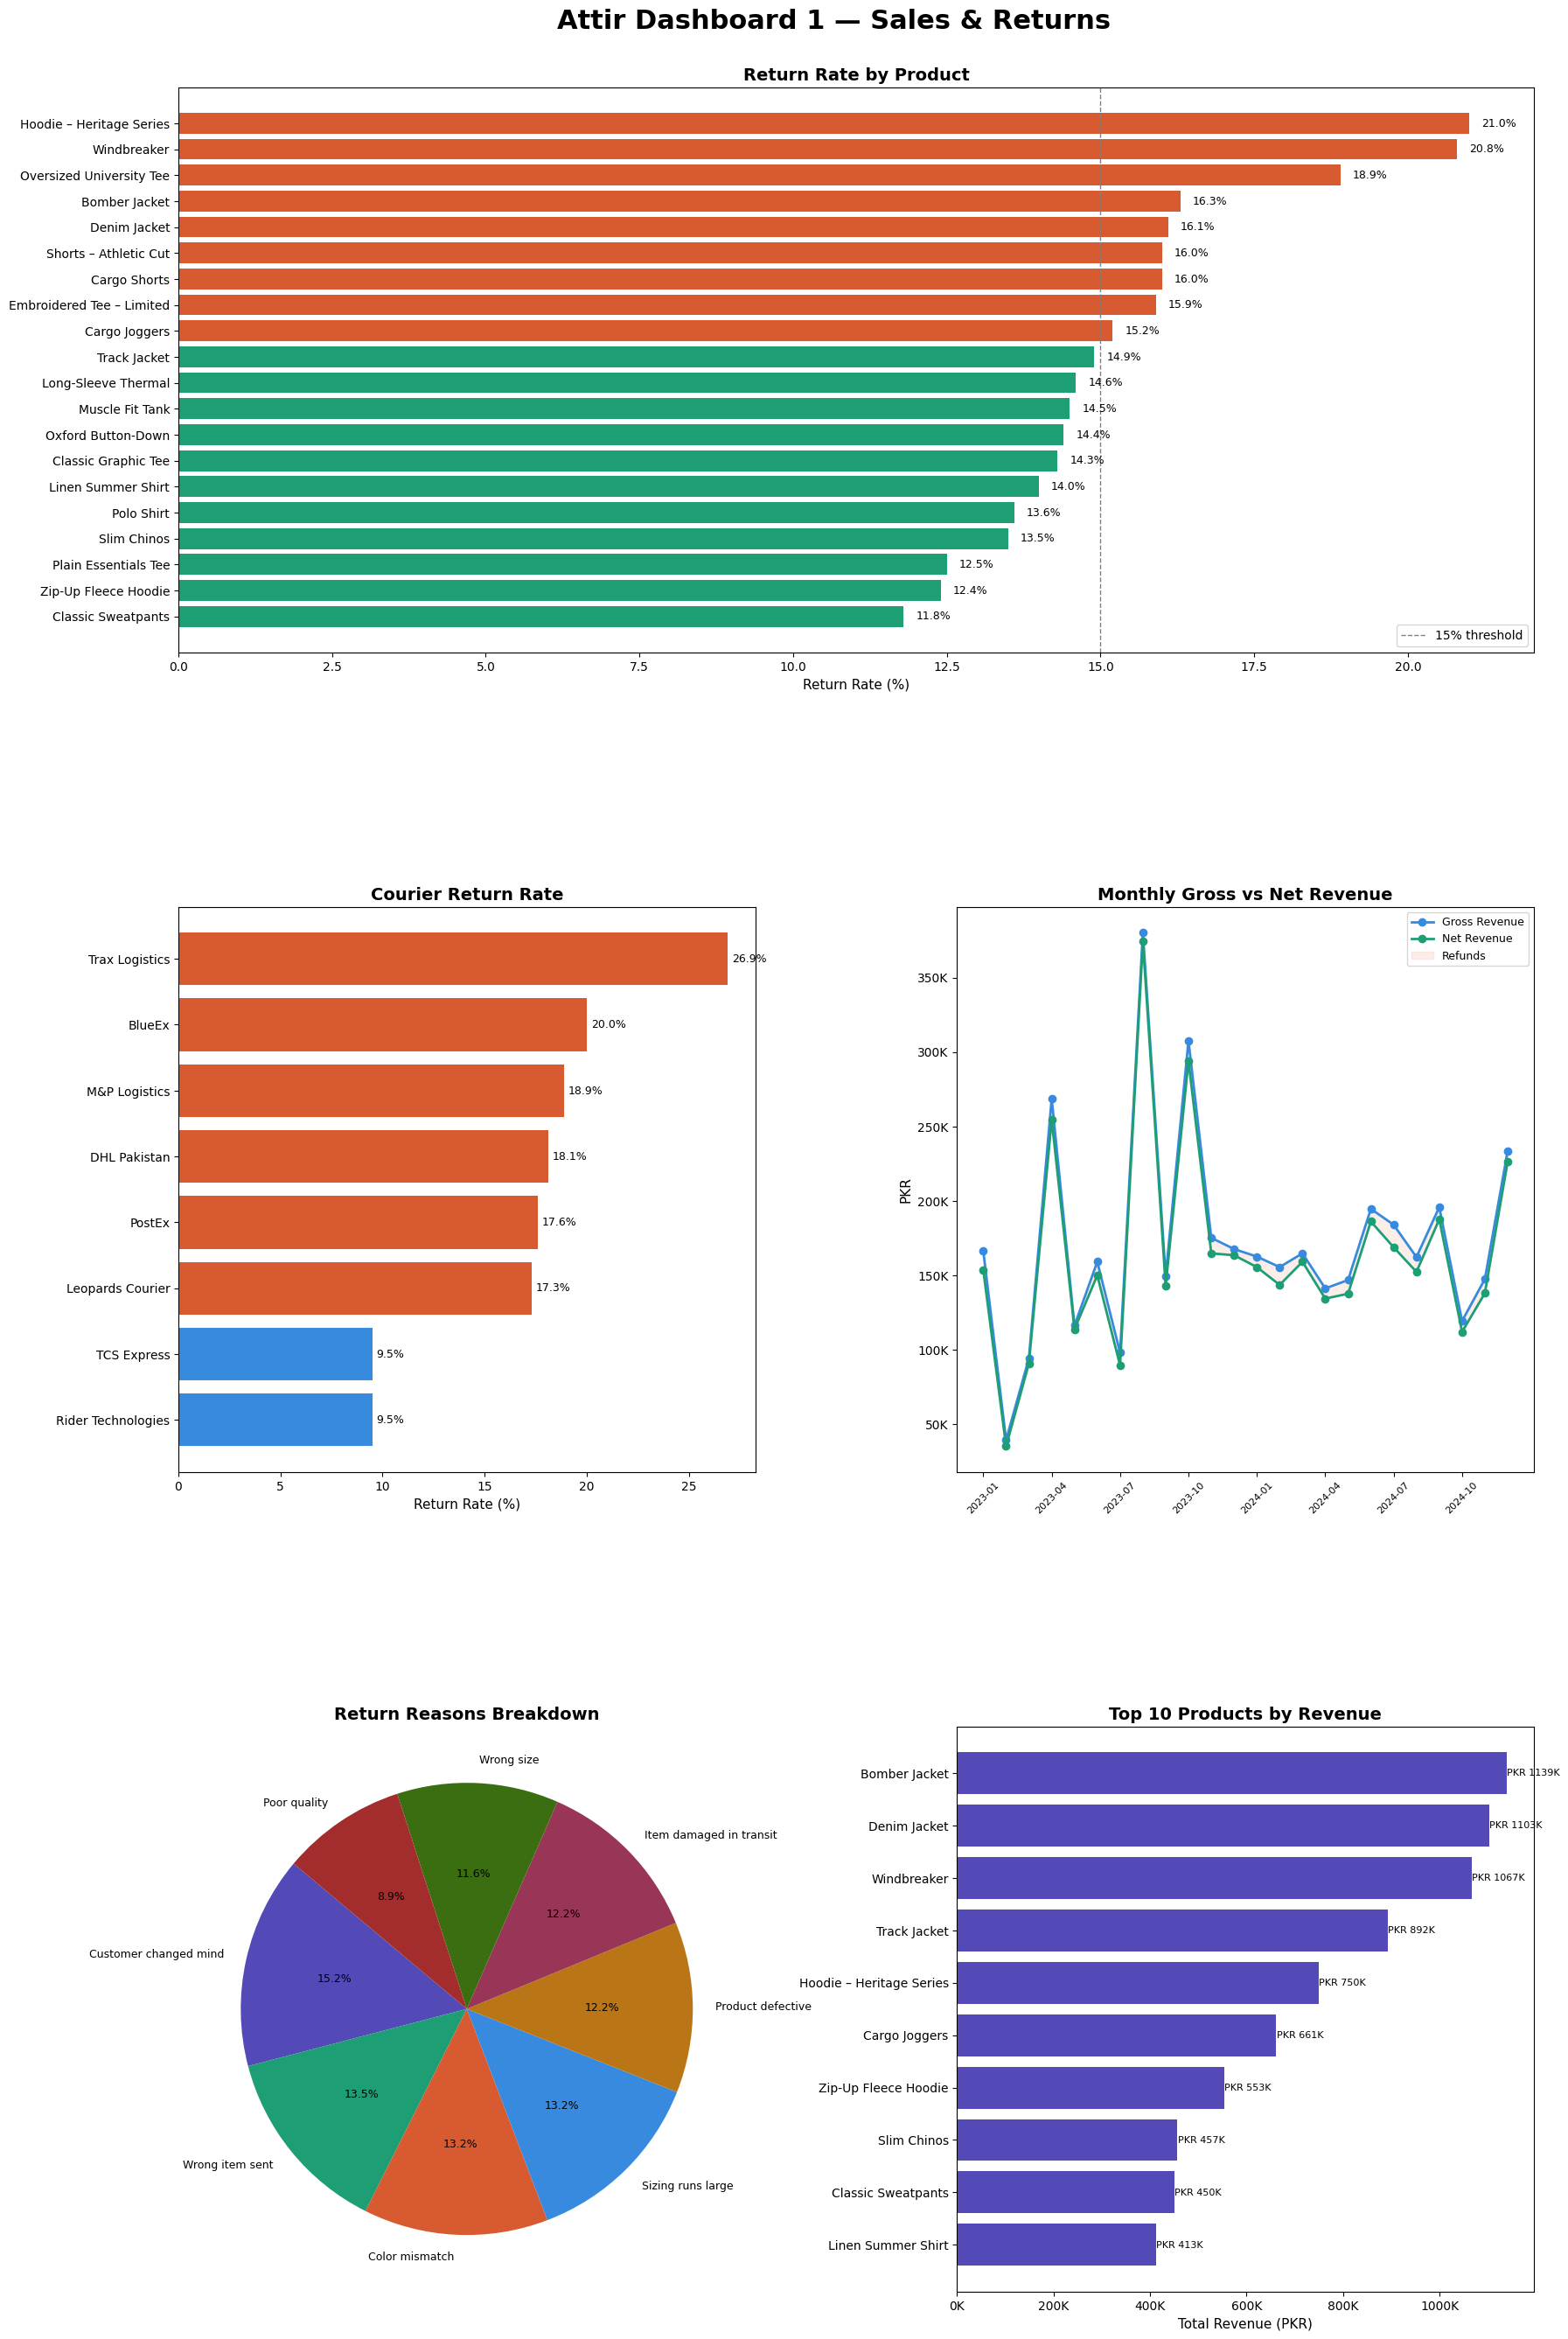

In [0]:
fig1 = plt.figure(figsize=(20, 30))
fig1.suptitle("Attir Dashboard 1 — Sales & Returns", fontsize=22, fontweight='bold', y=0.98)
gs1 = gridspec.GridSpec(3, 2, figure=fig1, hspace=0.45, wspace=0.35, top=0.95)

# ── CHART 1: Return rate by product ──────────────────────────────────────────
ax1 = fig1.add_subplot(gs1[0, :])

oi_ret = order_item.merge(ret, on="order_item_id", how="left")
oi_pv  = oi_ret.merge(product_variant, on="variant_id", how="left")
oi_p   = oi_pv.merge(product[["product_id","name","category"]], on="product_id", how="left")

sold    = oi_p.groupby("name")["order_item_id"].count().reset_index(name="units_sold")
returns = oi_p[oi_p["return_id"].notna()].groupby("name")["return_id"].count().reset_index(name="total_returns")
rr      = sold.merge(returns, on="name", how="left").fillna(0)
rr["return_rate"] = (rr["total_returns"] / rr["units_sold"] * 100).round(1)
rr = rr.sort_values("return_rate", ascending=True)

colors1 = ["#D85A30" if r > 15 else "#1D9E75" for r in rr["return_rate"]]
bars1 = ax1.barh(rr["name"], rr["return_rate"], color=colors1)
ax1.set_xlabel("Return Rate (%)", fontsize=11)
ax1.set_title("Return Rate by Product", fontsize=14, fontweight='bold')
ax1.axvline(x=15, color='gray', linestyle='--', linewidth=1, label='15% threshold')
ax1.legend(fontsize=10)
for bar, val in zip(bars1, rr["return_rate"]):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=9)

# ── CHART 2: Courier return rate ─────────────────────────────────────────────
ax2 = fig1.add_subplot(gs1[1, 0])

shp_c = shipment.merge(courier[["courier_id","name"]], on="courier_id", how="left")
total  = shp_c.groupby("name")["shipment_id"].count().reset_index(name="total")
ret_c  = shp_c[shp_c["status"]=="returned"].groupby("name")["shipment_id"].count().reset_index(name="returned")
coup   = total.merge(ret_c, on="name", how="left").fillna(0)
coup["return_rate"] = (coup["returned"] / coup["total"] * 100).round(1)
coup = coup.sort_values("return_rate", ascending=True)

colors2 = ["#D85A30" if r > 15 else "#378ADD" for r in coup["return_rate"]]
bars2 = ax2.barh(coup["name"], coup["return_rate"], color=colors2)
ax2.set_xlabel("Return Rate (%)", fontsize=11)
ax2.set_title("Courier Return Rate", fontsize=14, fontweight='bold')
for bar, val in zip(bars2, coup["return_rate"]):
    ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=9)

# ── CHART 3: Monthly gross vs net revenue ────────────────────────────────────
ax3 = fig1.add_subplot(gs1[1, 1])

order["order_date"] = pd.to_datetime(order["order_date"])
order["month"] = order["order_date"].dt.to_period("M").astype(str)
order["gross"] = order["subtotal"] - order["discount"] + order["shipping_fee"]

monthly_gross = order[order["status"] != "cancelled"].groupby("month")["gross"].sum().reset_index()
monthly_ref   = refund.merge(order[["order_id","month"]], on="order_id", how="left")
monthly_ref_s = monthly_ref.groupby("month")["amount"].sum().reset_index(name="refunds")
monthly       = monthly_gross.merge(monthly_ref_s, on="month", how="left").fillna(0)
monthly["net"] = monthly["gross"] - monthly["refunds"]
monthly = monthly.sort_values("month").tail(24)

ax3.plot(range(len(monthly)), monthly["gross"], marker='o', color="#378ADD", label="Gross Revenue", linewidth=2)
ax3.plot(range(len(monthly)), monthly["net"],   marker='o', color="#1D9E75", label="Net Revenue",   linewidth=2)
ax3.fill_between(range(len(monthly)), monthly["net"], monthly["gross"], alpha=0.1, color="#D85A30", label="Refunds")
ax3.set_xticks(range(0, len(monthly), 3))
ax3.set_xticklabels(monthly["month"].iloc[::3], rotation=45, fontsize=8)
ax3.set_ylabel("PKR", fontsize=11)
ax3.set_title("Monthly Gross vs Net Revenue", fontsize=14, fontweight='bold')
ax3.legend(fontsize=9)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# ── CHART 4: Return reasons breakdown ────────────────────────────────────────
ax4 = fig1.add_subplot(gs1[2, 0])

reasons = ret["reason"].value_counts().reset_index()
reasons.columns = ["reason", "count"]
colors4 = ["#534AB7","#1D9E75","#D85A30","#378ADD","#BA7517","#993556","#3B6D11","#A32D2D"]
ax4.pie(reasons["count"], labels=reasons["reason"], autopct='%1.1f%%',
        colors=colors4[:len(reasons)], startangle=140,
        textprops={'fontsize': 9})
ax4.set_title("Return Reasons Breakdown", fontsize=14, fontweight='bold')

# ── CHART 5: Top 10 products by revenue ──────────────────────────────────────
ax5 = fig1.add_subplot(gs1[2, 1])

oi_p2 = order_item.merge(product_variant[["variant_id","product_id"]], on="variant_id", how="left")
oi_p2 = oi_p2.merge(product[["product_id","name"]], on="product_id", how="left")
top_rev = oi_p2.groupby("name")["line_total"].sum().reset_index(name="revenue")
top_rev = top_rev.sort_values("revenue", ascending=True).tail(10)

bars5 = ax5.barh(top_rev["name"], top_rev["revenue"], color="#534AB7")
ax5.set_xlabel("Total Revenue (PKR)", fontsize=11)
ax5.set_title("Top 10 Products by Revenue", fontsize=14, fontweight='bold')
ax5.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar, val in zip(bars5, top_rev["revenue"]):
    ax5.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'PKR {val/1000:.0f}K', va='center', fontsize=8)

plt.savefig("attir_dashboard_1.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Dashboard 2 — Operations & Analytics
This dashboard covers Attir's operational and supply chain data across five visualizations:
- **Payment Method Breakdown** — shows the distribution of payment methods used by customers
- **Revenue by Product Category** — compares total revenue across Attir's product lines
- **Stock Levels vs Reorder Level** — flags products that are below their reorder threshold in red
- **Top 10 Customers by Spending** — identifies Attir's highest value customers
- **Purchase Order Value by Vendor** — compares total procurement spend across all vendor relationships

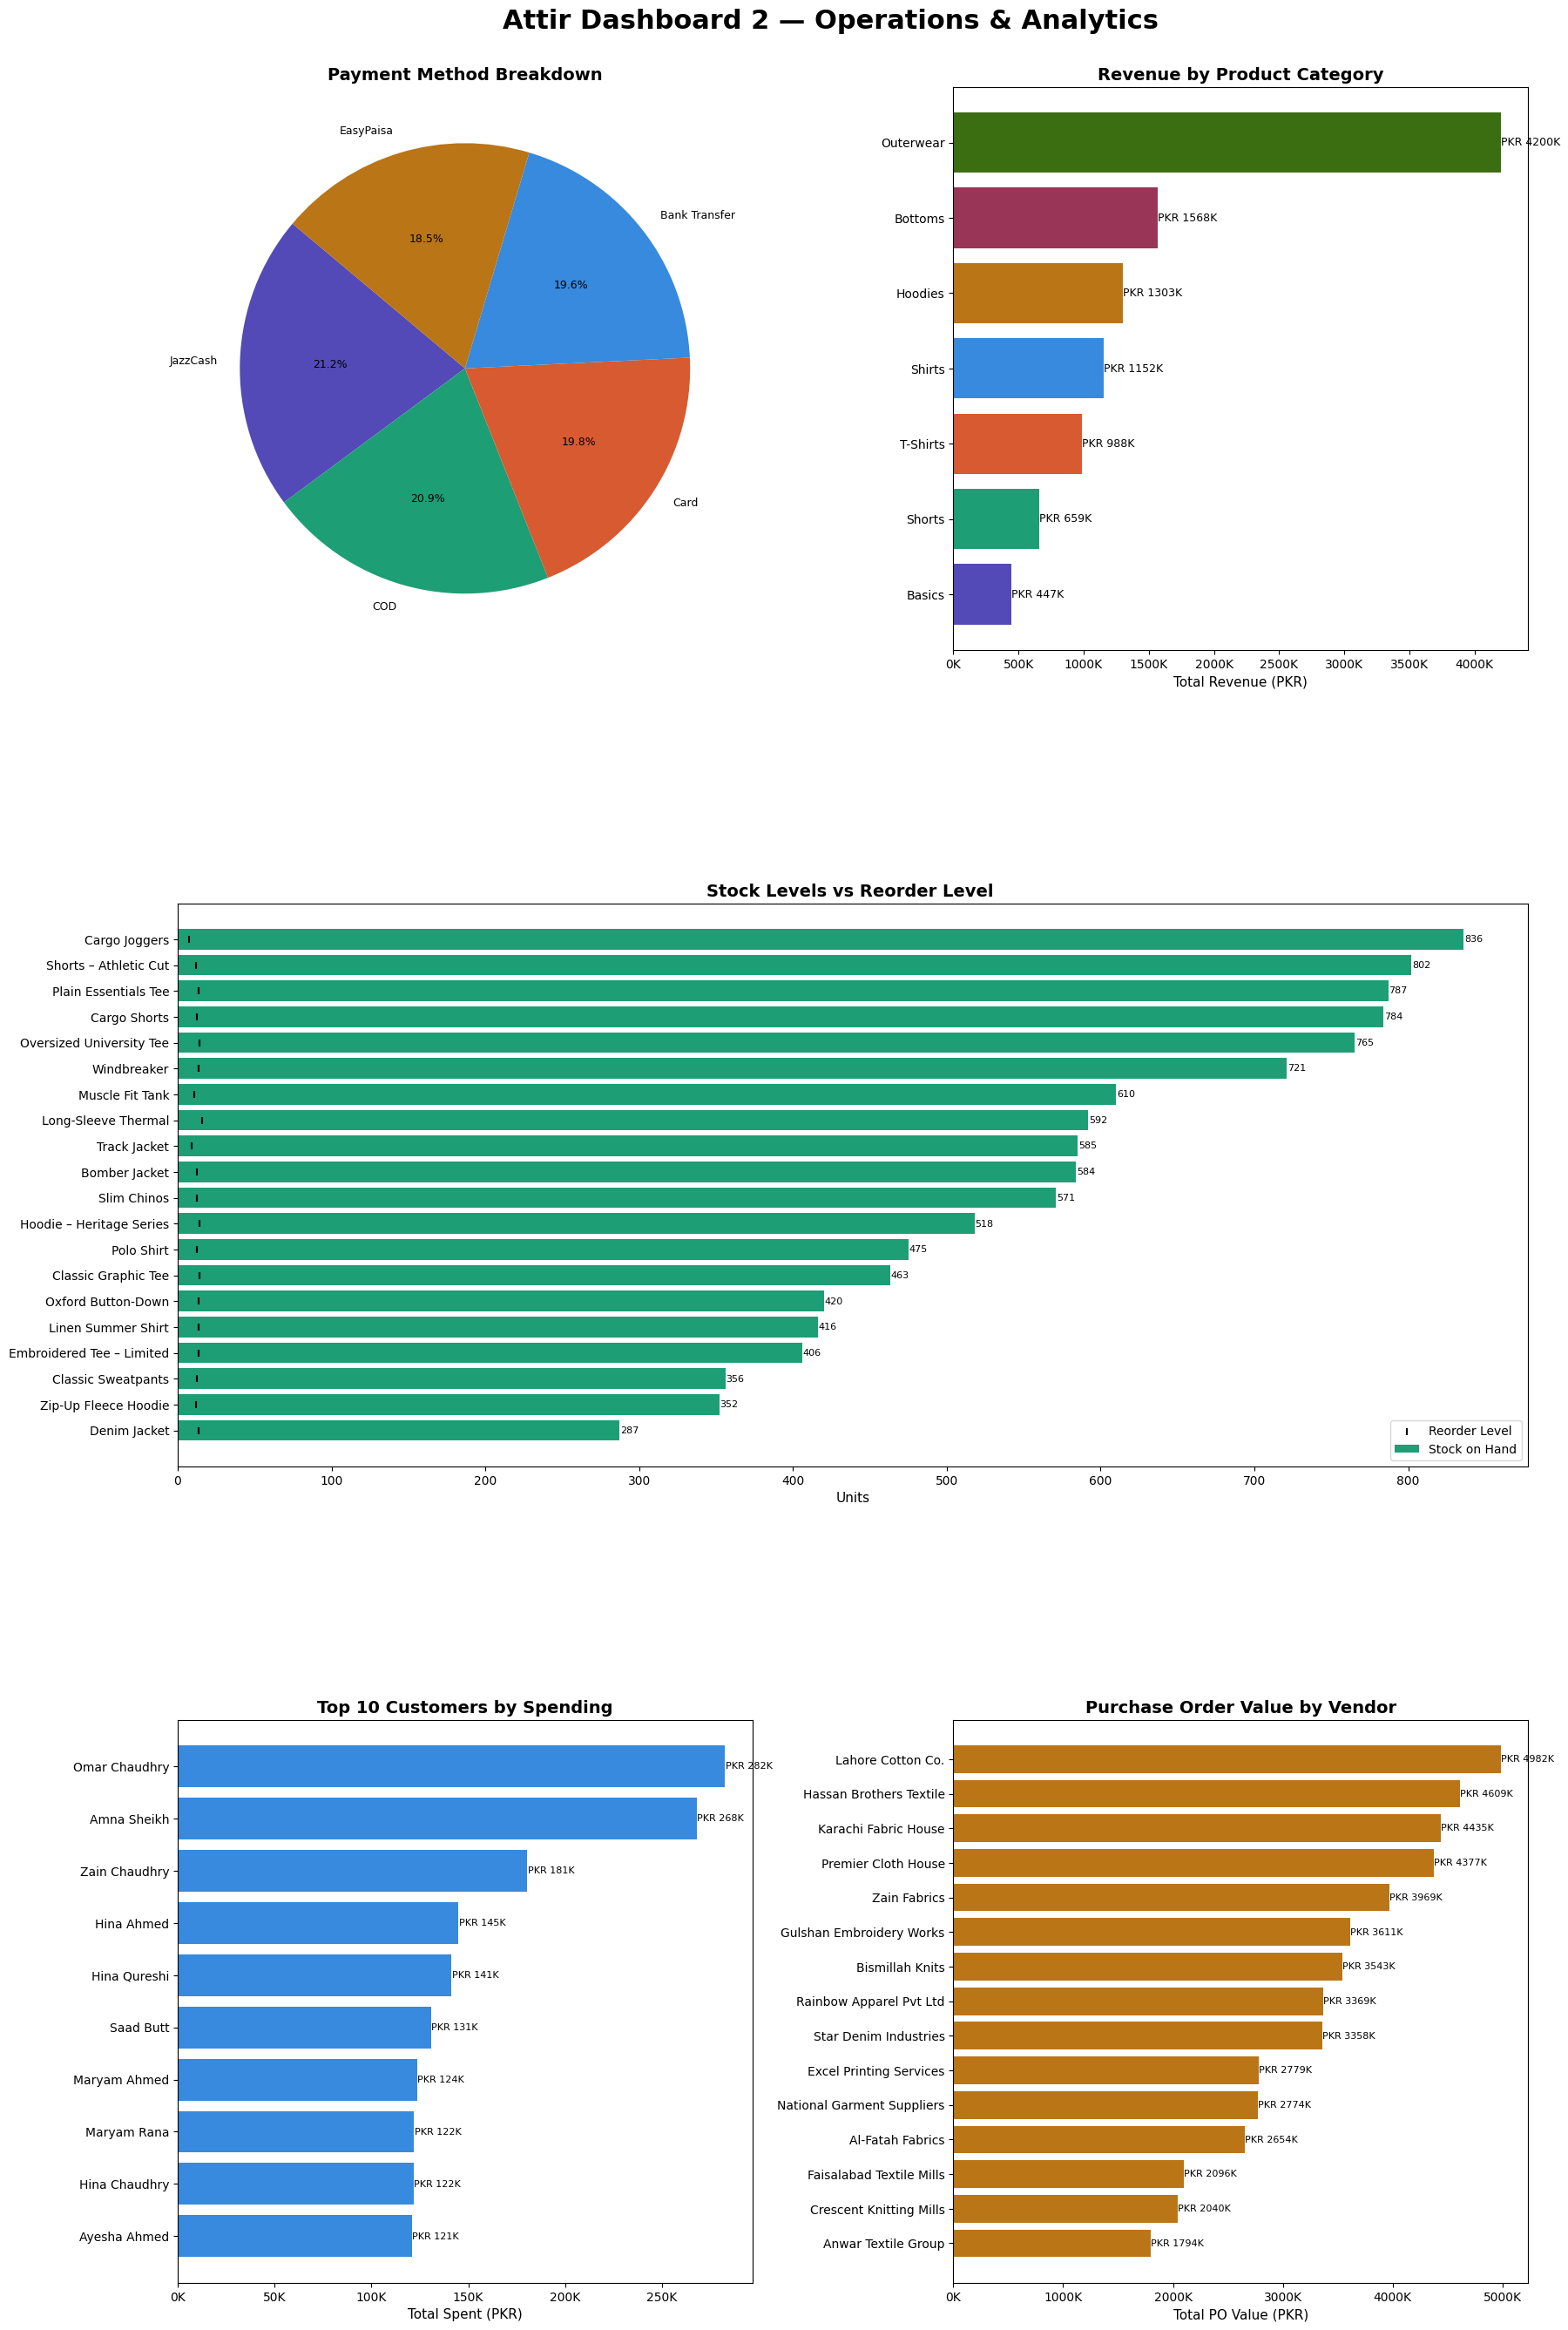

In [0]:
fig2 = plt.figure(figsize=(20, 30))
fig2.suptitle("Attir Dashboard 2 — Operations & Analytics", fontsize=22, fontweight='bold', y=0.98)
gs2 = gridspec.GridSpec(3, 2, figure=fig2, hspace=0.45, wspace=0.35, top=0.95)

# ── CHART 6: Payment method breakdown ────────────────────────────────────────
ax6 = fig2.add_subplot(gs2[0, 0])

pay_counts = payment["payment_method"].value_counts().reset_index()
pay_counts.columns = ["method", "count"]
colors6 = ["#534AB7","#1D9E75","#D85A30","#378ADD","#BA7517"]
ax6.pie(pay_counts["count"], labels=pay_counts["method"], autopct='%1.1f%%',
        colors=colors6[:len(pay_counts)], startangle=140,
        textprops={'fontsize': 9})
ax6.set_title("Payment Method Breakdown", fontsize=14, fontweight='bold')

# ── CHART 7: Revenue by product category ─────────────────────────────────────
ax7 = fig2.add_subplot(gs2[0, 1])

oi_cat = order_item.merge(product_variant[["variant_id","product_id"]], on="variant_id", how="left")
oi_cat = oi_cat.merge(product[["product_id","category"]], on="product_id", how="left")
cat_rev = oi_cat.groupby("category")["line_total"].sum().reset_index(name="revenue")
cat_rev = cat_rev.sort_values("revenue", ascending=True)

colors7 = ["#534AB7","#1D9E75","#D85A30","#378ADD","#BA7517","#993556","#3B6D11"]
bars7 = ax7.barh(cat_rev["category"], cat_rev["revenue"], color=colors7[:len(cat_rev)])
ax7.set_xlabel("Total Revenue (PKR)", fontsize=11)
ax7.set_title("Revenue by Product Category", fontsize=14, fontweight='bold')
ax7.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar, val in zip(bars7, cat_rev["revenue"]):
    ax7.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'PKR {val/1000:.0f}K', va='center', fontsize=9)

# ── CHART 8: Stock levels vs reorder level ───────────────────────────────────
ax8 = fig2.add_subplot(gs2[1, :])

inv_p = inventory.merge(product_variant[["variant_id","product_id"]], on="variant_id", how="left")
inv_p = inv_p.merge(product[["product_id","name"]], on="product_id", how="left")
inv_agg = inv_p.groupby("name").agg(
    quantity_on_hand=("quantity_on_hand","sum"),
    reorder_level=("reorder_level","mean")
).reset_index()
inv_agg = inv_agg.sort_values("quantity_on_hand", ascending=True)

colors8 = ["#D85A30" if q <= r else "#1D9E75" for q, r in zip(inv_agg["quantity_on_hand"], inv_agg["reorder_level"])]
bars8 = ax8.barh(inv_agg["name"], inv_agg["quantity_on_hand"], color=colors8, label="Stock on Hand")
ax8.scatter(inv_agg["reorder_level"], range(len(inv_agg)),
            color="black", zorder=5, s=40, label="Reorder Level", marker="|")
ax8.set_xlabel("Units", fontsize=11)
ax8.set_title("Stock Levels vs Reorder Level ", fontsize=14, fontweight='bold')
ax8.legend(fontsize=10)
for bar, val in zip(bars8, inv_agg["quantity_on_hand"]):
    ax8.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             str(int(val)), va='center', fontsize=8)

# ── CHART 9: Top 10 customers by spending ────────────────────────────────────
ax9 = fig2.add_subplot(gs2[2, 0])

cust_spend = order[order["status"] != "cancelled"].merge(
    customer[["customer_id","first_name","last_name"]], on="customer_id", how="left")
cust_spend["full_name"] = cust_spend["first_name"] + " " + cust_spend["last_name"]
cust_spend["gross"] = cust_spend["subtotal"] - cust_spend["discount"] + cust_spend["shipping_fee"]
top_cust = cust_spend.groupby("full_name")["gross"].sum().reset_index(name="total_spent")
top_cust = top_cust.sort_values("total_spent", ascending=True).tail(10)

bars9 = ax9.barh(top_cust["full_name"], top_cust["total_spent"], color="#378ADD")
ax9.set_xlabel("Total Spent (PKR)", fontsize=11)
ax9.set_title("Top 10 Customers by Spending", fontsize=14, fontweight='bold')
ax9.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar, val in zip(bars9, top_cust["total_spent"]):
    ax9.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f'PKR {val/1000:.0f}K', va='center', fontsize=8)

# ── CHART 10: Purchase order value by vendor ─────────────────────────────────
ax10 = fig2.add_subplot(gs2[2, 1])

po_vend = purchase_order.merge(vendor[["vendor_id","company_name"]], on="vendor_id", how="left")
vend_po = po_vend.groupby("company_name")["total_amount"].sum().reset_index(name="total_po_value")
vend_po = vend_po.sort_values("total_po_value", ascending=True)

bars10 = ax10.barh(vend_po["company_name"], vend_po["total_po_value"], color="#BA7517")
ax10.set_xlabel("Total PO Value (PKR)", fontsize=11)
ax10.set_title("Purchase Order Value by Vendor", fontsize=14, fontweight='bold')
ax10.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar, val in zip(bars10, vend_po["total_po_value"]):
    ax10.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'PKR {val/1000:.0f}K', va='center', fontsize=8)

plt.savefig("attir_dashboard_2.png", dpi=150, bbox_inches='tight')
plt.show()


## 5. Summary
The two dashboards above demonstrate the analytical value unlocked by Attir's new relational database. Insights that previously required hours of manual spreadsheet work, return patterns, courier performance, revenue trends, inventory health, are now generated instantly from a single source of truth. This forms the foundation for data-driven decision making as Attir scales.